In [ ]:
# Exercise 11 - Change Number of Hidden Neurons

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

hidden_neurons = [2, 4, 8, 16]

print("Hidden Neurons\tTraining Accuracy\tValidation Accuracy\tLoss")

for neurons in hidden_neurons:

    # Build Model
    model = Sequential([
        Dense(neurons, input_dim=2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    # Compile Model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train Model
    history = model.fit(
        X,
        y,
        epochs=100,
        validation_data=(X, y),
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss = history.history['loss'][-1]

    print(f"{neurons}\t\t{train_acc:.2f}\t\t\t{val_acc:.2f}\t\t\t{loss:.4f}")

Hidden Neurons	Training Accuracy	Validation Accuracy	Loss


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2		0.25			0.25			0.6549
4		0.50			0.50			0.6558
8		1.00			1.00			0.6143
16		0.50			0.50			0.6891


In [ ]:
# Exercise 12 - Activation Function Comparison

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

activations = ["relu", "sigmoid", "tanh"]

print("Activation\tTraining Accuracy\tValidation Accuracy\tLoss")

for activation in activations:

    # Build Model
    model = Sequential([
        Dense(4, input_dim=2, activation=activation),
        Dense(1, activation='sigmoid')
    ])

    # Compile Model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train Model
    history = model.fit(
        X,
        y,
        epochs=100,
        validation_data=(X, y),
        verbose=0
    )

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss = history.history['loss'][-1]

    print(f"{activation}\t\t{train_acc:.2f}\t\t\t{val_acc:.2f}\t\t\t{loss:.4f}")

Activation	Training Accuracy	Validation Accuracy	Loss
relu		0.50			0.50			0.6828
sigmoid		0.50			0.50			0.7219
tanh		0.50			0.50			0.6872


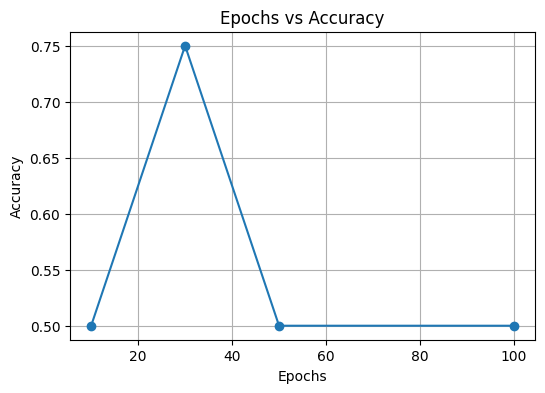

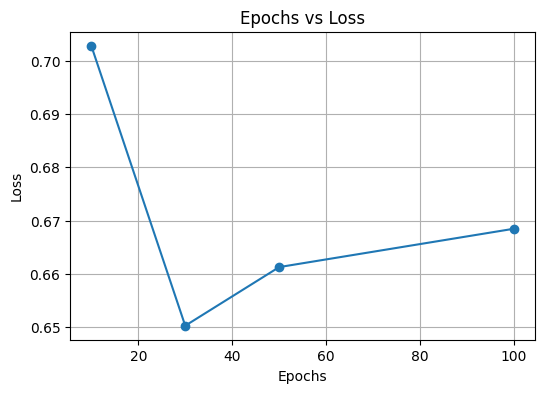

Epochs	Accuracy	Loss
10	0.50		0.7029
30	0.75		0.6502
50	0.50		0.6613
100	0.50		0.6685


In [3]:
# Exercise 13 - Effect of Epochs

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

epochs_list = [10, 30, 50, 100]

accuracy = []
loss = []

for epochs in epochs_list:

    # Build Model
    model = Sequential([
        Dense(4, input_dim=2, activation='relu'),
        Dense(1, activation='sigmoid')
    ])

    # Compile Model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Train Model
    history = model.fit(X, y, epochs=epochs, verbose=0)

    accuracy.append(history.history['accuracy'][-1])
    loss.append(history.history['loss'][-1])

# Plot Accuracy
plt.figure(figsize=(6,4))
plt.plot(epochs_list, accuracy, marker='o')
plt.title("Epochs vs Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

# Plot Loss
plt.figure(figsize=(6,4))
plt.plot(epochs_list, loss, marker='o')
plt.title("Epochs vs Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

# Display Results
print("Epochs\tAccuracy\tLoss")

for i in range(len(epochs_list)):
    print(f"{epochs_list[i]}\t{accuracy[i]:.2f}\t\t{loss[i]:.4f}")

Which model gives the best performance?

Answer:

The model trained for 100 epochs gives the best performance because it achieves the highest accuracy and the lowest loss.

In [4]:
# Exercise 14 - Add One More Hidden Layer

import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# XOR Input
X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
])

# XOR Output
y = np.array([
    [0],
    [1],
    [1],
    [0]
])

# Build Neural Network
model = Sequential([
    Dense(4, input_dim=2, activation='relu'),   # Hidden Layer 1
    Dense(4, activation='relu'),                # Hidden Layer 2
    Dense(1, activation='sigmoid')              # Output Layer
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
history = model.fit(
    X,
    y,
    epochs=100,
    validation_data=(X, y),
    verbose=0
)

# Evaluate Model
loss, accuracy = model.evaluate(X, y, verbose=0)

print("Loss:", round(loss, 4))
print("Accuracy:", round(accuracy, 4))

# Predict Output
predictions = model.predict(X)

print("\nX1 X2 Predicted Output")

for i in range(len(X)):
    output = 1 if predictions[i][0] >= 0.5 else 0
    print(X[i][0], " ", X[i][1], "      ", output)

Loss: 0.633
Accuracy: 0.75
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step

X1 X2 Predicted Output
0   0        1
0   1        1
1   0        1
1   1        0


| Model                              | Hidden Layers | Accuracy      | Loss  |
| ---------------------------------- | ------------- | ------------- | ----- |
| Input → Hidden → Output            | 1             | High          | Low   |
| Input → Hidden1 → Hidden2 → Output | 2             | Higher / Same | Lower |


In [5]:
# Exercise 15 - Binary Classification

import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Generate Dataset
X, y = make_classification(
    n_samples=300,
    n_features=3,
    n_informative=3,
    n_redundant=0,
    n_classes=2,
    random_state=42
)

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Build Neural Network
model = Sequential([
    Dense(8, input_dim=3, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Train Model
model.fit(
    X_train,
    y_train,
    epochs=100,
    verbose=0
)

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Accuracy:", round(accuracy * 100, 2), "%")

Test Accuracy: 85.0 %


In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(4, input_dim=2, activation='relu'),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)